In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.duplicated().sum()

np.int64(0)

data visualization

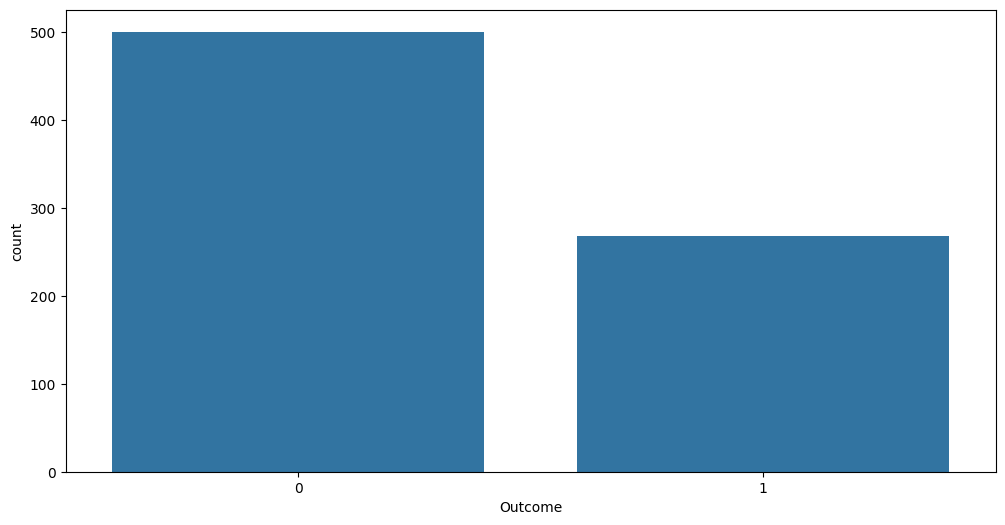

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(x='Outcome',data=df)
plt.show()

outlier detection or observation

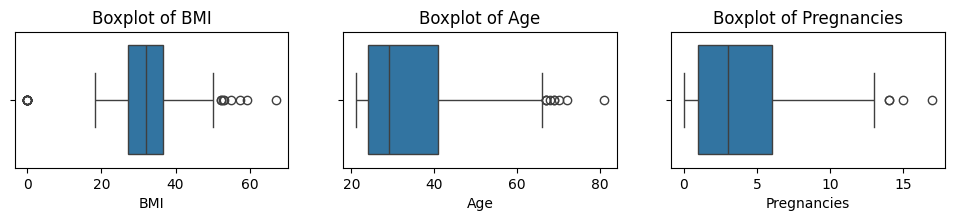

In [8]:
plt.figure(figsize=(12,6))
for i, col in enumerate(['BMI','Age','Pregnancies']):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=col,data=df)
    plt.title(f'Boxplot of {col}')
plt.show()

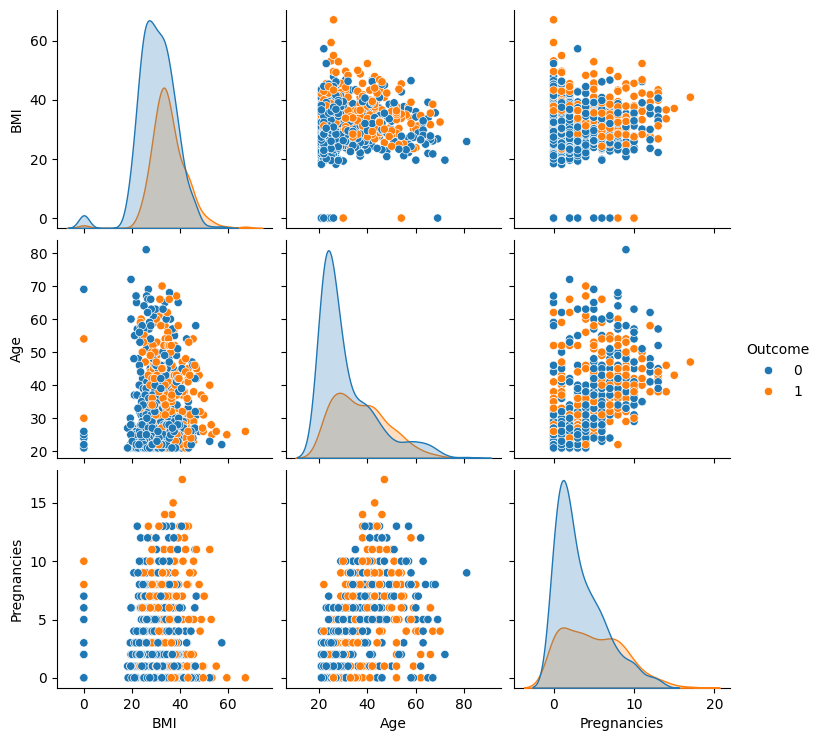

In [9]:
sns.pairplot(hue='Outcome',data=df[['BMI','Age','Outcome','Pregnancies']])
plt.show()

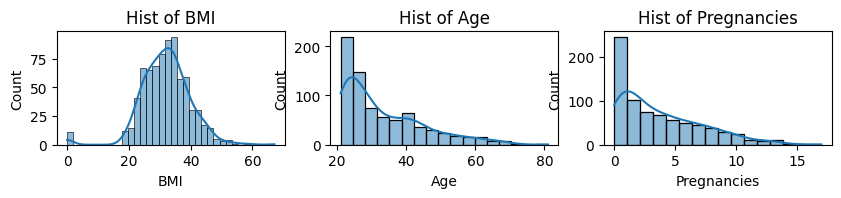

In [10]:
plt.figure(figsize=(10,5))
for i , col in enumerate(['BMI','Age','Pregnancies']):
    plt.subplot(3,3,i+1)
    sns.histplot(x=col , data=df , kde=True)
    plt.title(f'Hist of {col}')
plt.show()

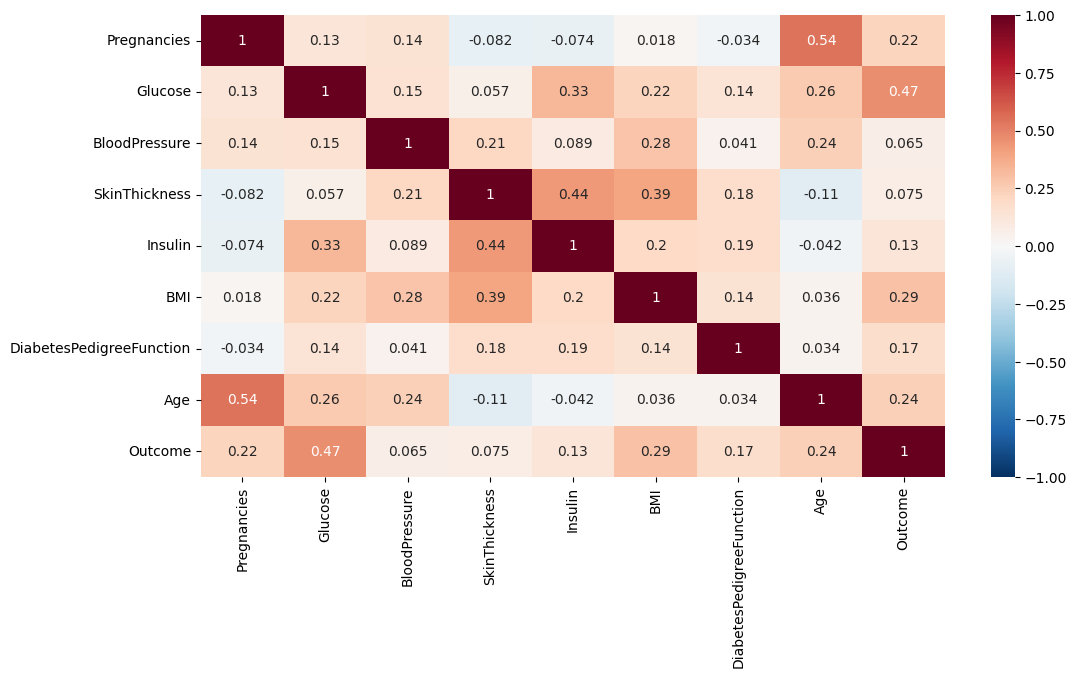

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),vmin=-1.0 , center= 0 , cmap="RdBu_r",annot=True)
plt.show()

using KNN 

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[['BMI','Age']].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:10])
print("--"*20)
print(X_test_scaled[:10])


[[-4.13525578 -1.03594038]
 [-0.48916881  1.48710085]
 [-0.42452187 -0.94893896]
 [-1.30372015  2.79212217]
 [ 1.83812075  1.13909516]
 [-0.78654469 -0.94893896]
 [ 0.11851236 -0.86193754]
 [-0.83826224  1.22609658]
 [ 0.4546764  -0.77493611]
 [-1.66574297 -1.03594038]]
----------------------------------------
[[ 0.26073561  0.87809089]
 [ 0.48053518 -1.03594038]
 [-0.15300476 -1.03594038]
 [-0.95462672  0.0950781 ]
 [-0.26936924  1.48710085]
 [ 0.7391229   1.92210795]
 [-1.49766095 -0.94893896]
 [ 0.23487683  0.96509232]
 [-0.08835783  0.35608237]
 [ 0.22194745  2.79212217]]


In [13]:

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled,y_train)

#evaluating model accuracy

y_pred = knn.predict(X_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred))

#predicting new sample
new_point = np.array([[45,20]])
new_point_scaled = scaler.transform(new_point)
new_pred = knn.predict(new_point_scaled)

if new_pred[0]  == 1:
    print("Your test may be postive")
else:
    print("your test may be negative")

Accuracy: 0.6363636363636364
your test may be negative


or we can also do this to find best accuracy

In [14]:
accuracies = []

for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred =  knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)# test set!
    print(accuracy)

    accuracies.append(accuracy)

# finding best accuracy
max_acc = max(accuracies)
best_k_index = accuracies.index(max_acc)
best_k = best_k_index + 1
print(f"Best K based on test accuracy: {best_k} with accuracy {max_acc*100:.2f}%")


0.6103896103896104
0.6623376623376623
0.6363636363636364
0.6363636363636364
0.6623376623376623
0.6623376623376623
0.6558441558441559
0.6298701298701299
0.6233766233766234
0.6103896103896104
0.6168831168831169
0.6298701298701299
0.6428571428571429
0.6298701298701299
Best K based on test accuracy: 2 with accuracy 66.23%


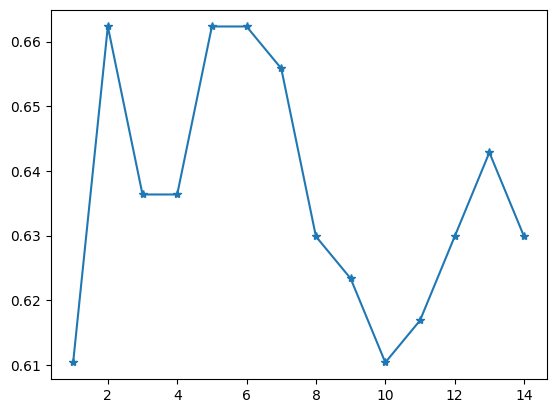

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(1, 15), accuracies, marker='*')
plt.show()




since k = 2 got a best accuray so
lets take k=2

In [16]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

new_point = np.array([[65 , 20]])
new_point_scaled = scaler.transform(new_point)
new_pred = knn.predict(new_point_scaled)

if new_pred[0] == 1:
    print("Your test may be positive")
else:
    print("Your test may be negative")

Your test may be positive
